# Step - 1 
# Business Problem Understanding

**The real estate company wants to predict the selling price of a house based on different property features such as area  number of rooms, lactionquality etc**

# Step - 2
# Data Understanding
**Understand each & every column**

In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.simplefilter("ignore")

In [2]:
df = pd.read_csv("house_price.csv")
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [4]:
df.shape

(1000, 8)

In [5]:
df["Square_Footage"].describe()

count    1000.000000
mean     2815.422000
std      1255.514921
min       503.000000
25%      1749.500000
50%      2862.500000
75%      3849.500000
max      4999.000000
Name: Square_Footage, dtype: float64

In [6]:
df["House_Price"].describe()

count    1.000000e+03
mean     6.188610e+05
std      2.535681e+05
min      1.116269e+05
25%      4.016482e+05
50%      6.282673e+05
75%      8.271413e+05
max      1.108237e+06
Name: House_Price, dtype: float64

In [7]:
df["Num_Bedrooms"].describe()

count    1000.000000
mean        2.990000
std         1.427564
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Num_Bedrooms, dtype: float64

In [8]:
df["Num_Bathrooms"].describe()

count    1000.000000
mean        1.973000
std         0.820332
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         3.000000
Name: Num_Bathrooms, dtype: float64

In [9]:
df["Neighborhood_Quality"].describe()

count    1000.000000
mean        5.615000
std         2.887059
min         1.000000
25%         3.000000
50%         6.000000
75%         8.000000
max        10.000000
Name: Neighborhood_Quality, dtype: float64

In [10]:
continous_feature = ["House_Price","Square_Footage","Lot_Size"]
discrete_count = ["Num_Bedrooms","Num_Bathrooms","Neighborhood_Quality","Garage_Size"]

In [11]:
df[continous_feature].describe()

,House_Price,Square_Footage,Lot_Size
count,1.000000e+03,1000.000000,1000.000000
mean,6.188610e+05,2815.422000,2.778087
std,2.535681e+05,1255.514921,1.297903
min,1.116269e+05,503.000000,0.506058
25%,4.016482e+05,1749.500000,1.665946
50%,6.282673e+05,2862.500000,2.809740
75%,8.271413e+05,3849.500000,3.923317
max,1.108237e+06,4999.000000,4.989303


In [12]:
df[continous_feature].skew()

House_Price      -0.063955
Square_Footage   -0.066001
Lot_Size         -0.044288
dtype: float64

In [13]:
df[discrete_count].describe()

,Num_Bedrooms,Num_Bathrooms,Neighborhood_Quality,Garage_Size
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.990000,1.973000,5.615000,1.022000
std,1.427564,0.820332,2.887059,0.814973
min,1.000000,1.000000,1.000000,0.000000
25%,2.000000,1.000000,3.000000,0.000000
50%,3.000000,2.000000,6.000000,1.000000
75%,4.000000,3.000000,8.000000,2.000000
max,5.000000,3.000000,10.000000,2.000000


In [14]:
df[discrete_count].skew()

Num_Bedrooms            0.025884
Num_Bathrooms           0.049917
Neighborhood_Quality   -0.020445
Garage_Size            -0.040400
dtype: float64

In [15]:
df[continous_feature].corr()

,House_Price,Square_Footage,Lot_Size
House_Price,1.000000,0.991261,0.160412
Square_Footage,0.991261,1.000000,0.089479
Lot_Size,0.160412,0.089479,1.000000


In [16]:
df

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


In [17]:
df = df.drop("Garage_Size",axis=1)

In [18]:
df

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,5,2.623829e+05
1,4272,3,3,2016,4.753014,6,9.852609e+05
2,3592,1,2,2016,3.634823,9,7.779774e+05
3,966,1,2,1977,2.730667,8,2.296989e+05
4,4926,2,1,1993,4.699073,8,1.041741e+06
...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,10,7.014940e+05
996,3179,1,2,1999,2.977123,10,6.837232e+05
997,2606,4,2,1962,4.055067,2,5.720240e+05
998,4723,5,2,1950,1.930921,7,9.648653e+05


In [19]:
X = df.drop("House_Price",axis=1)
y = df["House_Price"]

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=0) 

In [21]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()

model_lr.fit(X_train,y_train)

LinearRegression()

In [22]:
print("intercept:",model_lr.intercept_)
print("coefficient:",model_lr.coef_)

intercept: -2021267.091303847
coefficient: [  199.91945293 10350.57672674  7962.02141115  1000.86087729
 14916.86814263   135.65417718]


In [23]:
train = []
CV = []
for i in range(0,101):
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2,random_state=i)
    
    from sklearn.linear_model import LinearRegression
    model_lr = LinearRegression()
    model_lr.fit(X_train,y_train)
    
    #Pridiction on train data
    ypred_train = model_lr.predict(X_train)
  

    #Evaluation train data 
    from sklearn.metrics import r2_score
    train.append(r2_score(y_train,ypred_train))
    
    # Cross Validation on train data 
    from sklearn.model_selection import cross_val_score
    CV.append(cross_val_score(model_lr,X_train,y_train,cv=5,).mean())

em = pd.DataFrame({"train" : train, "CV": CV})
gm = em[(abs(em["train"]-em["CV"])<=0.05)]
rs = gm[gm["CV"]==gm["CV"].max()].index.tolist()[0]
print("best random state number :",rs)

best random state number : 0


In [24]:
ypred_train = model_lr.predict(X_train)
#Evaluation train data 
from sklearn.metrics import r2_score
print("Train R2:",r2_score(y_train,ypred_train))
#Pridiction on test data
ypred_test = model_lr.predict(X_test)

#Evaluation test data 
from sklearn.metrics import r2_score
print("Test R2:",r2_score(y_test,ypred_test))
# Cross Validation on train data 
from sklearn.model_selection import cross_val_score
print("Cross Validation Score is :",cross_val_score(model_lr,X_train,y_train,cv=5,).mean())

Train R2: 0.9981892381674089
Test R2: 0.9984613606530836
Cross Validation Score is : 0.9981410448377673


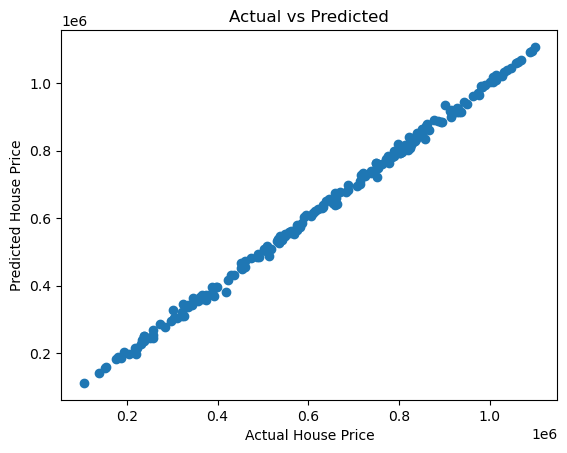

In [27]:
plt.scatter(ypred_test,y_test)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted")
plt.show()

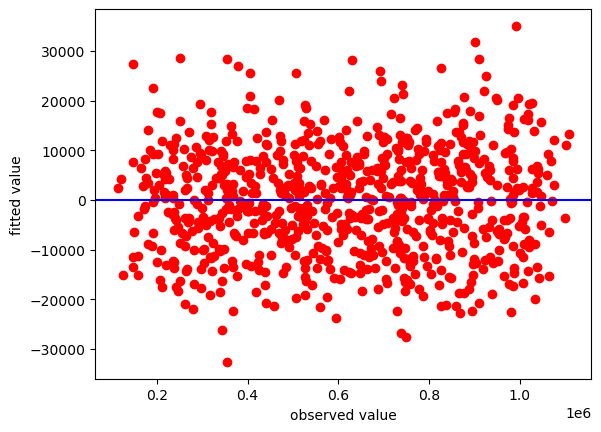

In [30]:
#Linearity error
train_error = y_train - ypred_train

plt.scatter(y_train,train_error,c="r")
plt.axhline(y=0,color="blue")
plt.xlabel("observed value")
plt.ylabel("fitted value")
plt.show()

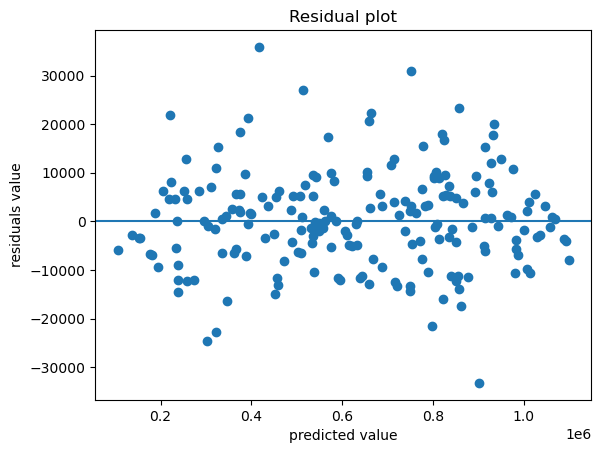

In [28]:
residuals = ypred_test - y_test
plt.scatter(ypred_test , residuals)
plt.axhline(y=0)
plt.xlabel("predicted value")
plt.ylabel("residuals value")
plt.title("Residual plot")
plt.show()

In [31]:
ypred_test = model_lr.predict(X_test)

In [32]:
comparison = pd.DataFrame({"Actual Price":y_test.values,
                          "predicated price":ypred_test})

comparison.head()

,Actual Price,predicated price
0,3.817380e+05,4.176256e+05
1,8.243517e+05,8.297124e+05
2,1.043830e+06,1.047062e+06
3,5.729414e+05,5.812640e+05
4,2.368654e+05,2.369142e+05


In [37]:
X = df.drop("House_Price",axis=1)
y = df["House_Price"]

In [38]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=0) 

In [39]:
from sklearn.linear_model import Lasso
lasso_best = Lasso()

lasso_best.fit(X_train,y_train)
print("intercept:",lasso_best.intercept_)
print("coefficient:",lasso_best.coef_)

ypred_train = lasso_best.predict(X_train)
from sklearn.metrics import r2_score 
print("Train R2 :",r2_score(y_train,ypred_train))

#Cross validdation on train data
from sklearn.model_selection import cross_val_score
print("Cross Validation Score :",cross_val_score(lasso_best,X_train,y_train,cv=5).mean())

ypred_test = lasso_best.predict(X_test)
from sklearn.metrics import r2_score 
print("Test R2 :",r2_score(y_test,ypred_test))


intercept: -2021245.358059413
coefficient: [  199.91945401 10350.06183751  7960.56026075  1000.85328596
 14916.304364     135.53691856]
Train R2 : 0.9983350795707537
Cross Validation Score : 0.9982998496641828
Test R2 : 0.9978403430142891


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Neighborhood_Quality  1000 non-null   int64  
 6   House_Price           1000 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 54.8 KB


In [41]:
from sklearn.model_selection import GridSearchCV

#model
from sklearn.linear_model import Lasso
estimator = Lasso()

#Prameter & values
param_grid = {"alpha" : list(range(1,100))}

#identify the best value of the parmeter within given values for the given data
model_hp = GridSearchCV(estimator,param_grid,cv=5,scoring="r2")

model_hp.fit(X_train,y_train)

model_hp.best_params_

{'alpha': 66}

In [42]:
from sklearn.linear_model import Lasso
lasso_best = Lasso(alpha=66)

lasso_best.fit(X_train,y_train)
print("intercept:",lasso_best.intercept_)
print("coefficient:",lasso_best.coef_)

ypred_train = lasso_best.predict(X_train)
from sklearn.metrics import r2_score 
print("Train R2 :",r2_score(y_train,ypred_train))

#Cross validdation on train data
from sklearn.model_selection import cross_val_score
print("Cross Validation Score :",cross_val_score(lasso_best,X_train,y_train,cv=5).mean())

ypred_test = lasso_best.predict(X_test)
from sklearn.metrics import r2_score 
print("Test R2 :",r2_score(y_test,ypred_test))


intercept: -2019832.6627452017
coefficient: [  199.9195212  10316.59305712  7865.58482664  1000.35983801
 14879.65907811   127.91505916]
Train R2 : 0.9983349013659131
Cross Validation Score : 0.9983000313999533
Test R2 : 0.9978349446543742


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Neighborhood_Quality  1000 non-null   int64  
 6   House_Price           1000 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 54.8 KB


In [46]:
input_data = {"Square_Footage":4500,
             "Num_Bedrooms": 8,
             "Num_Bathrooms":5,
             "Year_Built": 2025,
             "Lot_Size": 1.5,
             "Neighborhood_Quality":9}

df_test = pd.DataFrame(input_data,index=[0])
df_test

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Neighborhood_Quality
0,4500,8,5,2025,1.5,9


In [47]:
lasso_best.predict(df_test)

array([1050865.24738455])